# Final Project: Fine-Grained Visual Categorization (FGVC) of Cars with PyTorch

**Course:** Deep Learning (DL) – 2026-1  
**Project Title:** Fine-Grained Classification on Stanford Cars Dataset with Convolutional Neural Networks and Transformers  
**Members:** [Member Name 1], [Member Name 2]

## Project Summary
This notebook provides the complete pipeline for the Fine-Grained Visual Categorization (FGVC) task. The goal is to implement and evaluate Deep Learning models capable of identifying the make, model, and year of vehicles in the Stanford Cars dataset. The workflow covers preprocessing, implementation of Transfer Learning strategies in two phases, and interpretability techniques via activation maps.

## 1. Introduction and Problem Description
Fine-Grained Visual Categorization (FGVC) is a computer vision subfield that deals with categories belonging to the same meta-class (in this case, cars). Unlike generic classification (e.g., cat vs. dog), FGVC presents specific challenges:

1. **Small inter-class variation**: The differences between categories (e.g., BMW M3 vs. BMW M5) are minimal, residing in subtle details like the design of the front grille or the shape of the headlights.
2. **Large intra-class variation**: The same car model can have drastically different appearances due to variations in lighting, capture angles (perspective), partial occlusions, and colors.

**The Stanford Cars Dataset:**
* Volume: 16,185 images.
* Classes: 196 categories detailed by Make, Model, and Year.

## 2. Hypothesis and Methodology

**Technical and Mathematical Foundation:**
The problem is modeled as a multi-class classification task where we seek to minimize the Cross-Entropy Loss function.

**Central Hypothesis:**
Architectures that use global attention mechanisms, like the Vision Transformer (ViT), or highly efficient feature extraction, like EfficientNet, will outperform the ResNet50 baseline.

**Transfer Learning Methodology:**
We will use pre-trained weights on ImageNet. The strategy will be divided into:
1. **Warm-up Phase**: Freezing the feature extractor and optimizing only the new linear head.
2. **Global Fine-Tuning**: Unfreezing all parameters and applying an optimizer with a reduced learning rate.


## 3. Setup Dependencies and Shared Functions


In [67]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, models, transforms
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader, random_split, Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cv2
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import scipy.io
import os
import copy
from datetime import datetime
from tqdm.auto import tqdm
import glob
import json

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

# Global Loss Function
criterion = nn.CrossEntropyLoss()

# Setup Data Directory
os.makedirs('./data', exist_ok=True)
os.makedirs('./models', exist_ok=True)
DOWNLOAD_DATASET = False

# Training Flags (Set to False to load the latest saved model from ./models)
TRAIN_RESNET = False  
TRAIN_EFFICIENTNET = False

# ImageNet normalization parameters
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]


Running on: cuda


### 3.1 Shared Dataloader Factory


In [68]:
class BBoxStanfordCars(Dataset):
    def __init__(self, root, split='train', transform=None):
        self.root = root
        self.split = split
        self.transform = transform
        
        if split == 'train':
            mat_path = os.path.join(root, 'stanford_cars', 'devkit', 'cars_train_annos.mat')
            self.img_dir = os.path.join(root, 'stanford_cars', 'cars_train')
        else:
            mat_path = os.path.join(root, 'stanford_cars', 'cars_test_annos_withlabels.mat')
            self.img_dir = os.path.join(root, 'stanford_cars', 'cars_test')
            
        mat = scipy.io.loadmat(mat_path)
        self.annotations = mat['annotations'][0]
        
    def __len__(self):
        return len(self.annotations)
        
    def __getitem__(self, idx):
        anno = self.annotations[idx]
        x1, y1, x2, y2 = anno[0][0][0], anno[1][0][0], anno[2][0][0], anno[3][0][0]
        label = anno[4][0][0] - 1  # PyTorch expects 0-indexed labels
        fname = anno[5][0]
        
        img_path = os.path.join(self.img_dir, fname)
        img = Image.open(img_path).convert('RGB')
        
        # 1. Crop using Bounding Box
        img = img.crop((x1, y1, x2, y2))
        
        # 2. Square Padding to preserve aspect ratio without distortion
        w, h = img.size
        max_dim = max(w, h)
        pad_left = (max_dim - w) // 2
        pad_top = (max_dim - h) // 2
        pad_right = max_dim - w - pad_left
        pad_bottom = max_dim - h - pad_top
        
        img = TF.pad(img, (pad_left, pad_top, pad_right, pad_bottom), fill=0)
        
        if self.transform:
            img = self.transform(img)
            
        return img, label

def create_dataloaders(img_size, resize_size, batch_size=32):
    data_transforms = {
        'train': transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ]),
        'test': transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ]),
    }
    
    try:
        full_train_dataset = BBoxStanfordCars(root='./data', split='train', transform=data_transforms['train'])
        test_dataset = BBoxStanfordCars(root='./data', split='test', transform=data_transforms['test'])
        
        # Fixed generator seed to ensure identical validation splits for both pipelines!
        gen = torch.Generator().manual_seed(42)
        
        total_train_size = len(full_train_dataset)
        val_size = int(0.15 * total_train_size)
        train_size = total_train_size - val_size
        
        train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=gen)
        
        # Deep copy the dataset for validation so we can apply the test transform (no augmentation) without affecting training
        val_dataset.dataset = copy.deepcopy(full_train_dataset)
        val_dataset.dataset.transform = data_transforms['test']
        
        # Setting num_workers=0 is critical on Windows to prevent Jupyter Notebook from hanging during multiprocessing!
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
        
        print(f"Created DataLoaders for sizes: BBox Crop -> Pad -> Resize={img_size} | Batch Size={batch_size}")
        print(f"--> Train size: {len(train_dataset)}")
        print(f"--> Val size:   {len(val_dataset)}")
        print(f"--> Test size:  {len(test_dataset)}")
        return train_loader, val_loader, test_loader
        
    except Exception as e:
        print(f"Dataset load error: {e}")
        return None, None, None


### 3.1.1 Bounding Box Pre-Processing Visualization


Here we visualize what our `BBoxStanfordCars` dataset class is actually doing. It crops the image exactly to the bounding box containing the car, and then applies square black padding so the car's aspect ratio isn't stretched or distorted when resized!


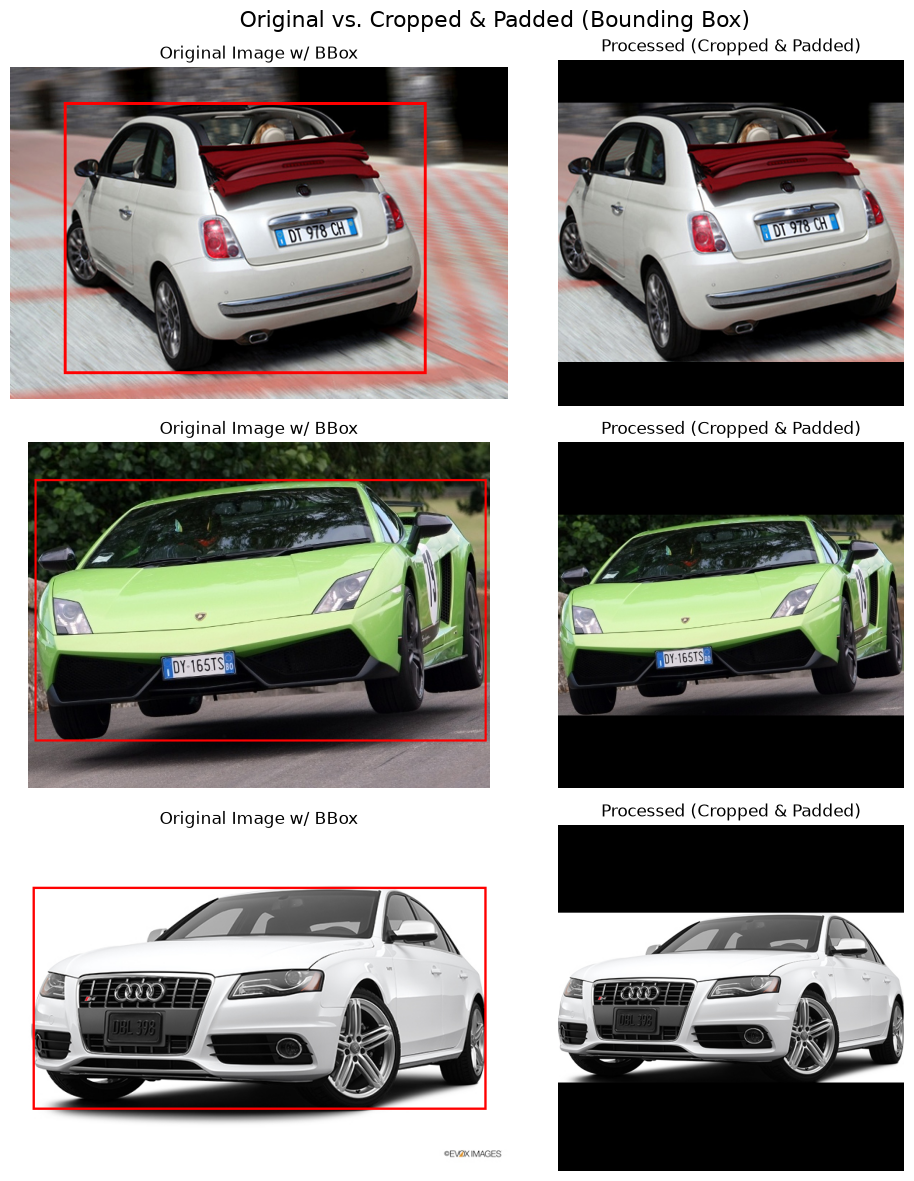

In [69]:

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import random

def visualize_bounding_boxes(dataset_root='./data', split='train', num_samples=3):
    # Load dataset without transforms to get the raw cropped/padded PIL images
    viz_dataset = BBoxStanfordCars(root=dataset_root, split=split, transform=None)
    
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    fig.suptitle('Original vs. Cropped & Padded (Bounding Box)', fontsize=16)
    
    # Pick random samples
    random.seed(42)
    indices = random.sample(range(len(viz_dataset)), num_samples)
    
    for i, idx in enumerate(indices):
        # 1. Get the raw uncropped image and its bounding box
        anno = viz_dataset.annotations[idx]
        x1, y1, x2, y2 = anno[0][0][0], anno[1][0][0], anno[2][0][0], anno[3][0][0]
        fname = anno[5][0]
        img_path = os.path.join(viz_dataset.img_dir, fname)
        
        orig_img = Image.open(img_path).convert('RGB')
        
        # Draw red bounding box on original image
        draw = ImageDraw.Draw(orig_img)
        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
        
        axes[i, 0].imshow(orig_img)
        axes[i, 0].set_title(f"Original Image w/ BBox")
        axes[i, 0].axis('off')
        
        # 2. Get the cropped & padded output directly from our Dataset class
        cropped_padded_img, label = viz_dataset[idx]
        
        axes[i, 1].imshow(cropped_padded_img)
        axes[i, 1].set_title(f"Processed (Cropped & Padded)")
        axes[i, 1].axis('off')
        
    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_bounding_boxes()



### 3.2 Model Initialization and Training Logic


In [70]:
def initialize_model(model_name, num_classes=196):
    if model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
    elif model_name == "efficientnet_b4":
        model = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_ftrs, num_classes)
    else:
        raise ValueError("Model name not supported.")
    return model.to(device)

def train_model(model, train_loader, val_loader, optimizer, num_epochs=10):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs} ', end='')
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader
                
            running_loss = 0.0
            running_corrects = 0
            
            # Wrap dataloader in tqdm for a progress bar
            pbar = tqdm(dataloader, desc=f"{phase.capitalize()} Epoch {epoch+1}/{num_epochs}", leave=False)
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
                # Update progress bar description with current running loss
                pbar.set_postfix({'loss': loss.item()})
                
            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
                print(f'[Train: Loss {epoch_loss:.4f}, Acc {epoch_acc:.4f}] ', end='')
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                print(f'[Val: Loss {epoch_loss:.4f}, Acc {epoch_acc:.4f}]')
                
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    
    print(f'Best Validation Accuracy: {best_acc:.4f}')
    model.load_state_dict(best_model_wts)
    return history


### 3.3 Evaluation & Visualization Utilities


In [71]:
def plot_metrics(history, title, save_dir=None):
    epochs = range(len(history['train_loss']))
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
    if 'val_loss' in history and len(history['val_loss']) > 0:
        plt.plot(epochs, history['val_loss'], label='Val Loss', marker='o')
    plt.title(f'{title} - Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Accuracy', marker='o')
    if 'val_acc' in history and len(history['val_acc']) > 0:
        plt.plot(epochs, history['val_acc'], label='Val Accuracy', marker='o')
    plt.title(f'{title} - Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    if save_dir:
        plt.savefig(os.path.join(save_dir, 'metrics.png'), bbox_inches='tight', dpi=300)
    plt.show()

def generate_confusion_matrix(model, test_loader, title, save_dir=None):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    cm = confusion_matrix(all_labels, all_preds)
    
    # Plot 1: Detailed Subset (First 20 Classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm[:20, :20], annot=True, fmt='d', cmap='Blues')
    plt.title(f'{title} - Confusion Matrix (Subset 20 Classes)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    if save_dir:
        plt.savefig(os.path.join(save_dir, 'confusion_matrix_subset.png'), bbox_inches='tight', dpi=300)
    plt.show()
    
    # Plot 2: Full Distribution Heatmap (All 196 Classes)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, cmap='Blues', cbar=True, xticklabels=False, yticklabels=False)
    plt.title(f'{title} - Full Confusion Matrix (All 196 Classes)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    if save_dir:
        plt.savefig(os.path.join(save_dir, 'confusion_matrix_full.png'), bbox_inches='tight', dpi=300)
    plt.show()

def generate_gradcam(model, target_layer, input_tensor):
    gradients, activations = [], []
    def backward_hook(module, grad_input, grad_output): gradients.append(grad_output[0])
    def forward_hook(module, input, output): activations.append(output)

    # Force-clear any stuck hooks
    import collections
    if hasattr(target_layer, '_backward_hooks'): target_layer._backward_hooks = collections.OrderedDict()
    if hasattr(target_layer, '_forward_hooks'): target_layer._forward_hooks = collections.OrderedDict()
    if hasattr(target_layer, '_is_full_backward_hook'): target_layer._is_full_backward_hook = None

    handle_backward = target_layer.register_full_backward_hook(backward_hook)
    handle_forward = target_layer.register_forward_hook(forward_hook)

    model.eval()
    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()
    
    model.zero_grad()
    output[0, pred_class].backward()

    pooled_gradients = torch.mean(gradients[0], dim=[0, 2, 3])
    for i in range(activations[0].shape[1]):
        activations[0][:, i, :, :] *= pooled_gradients[i]

    heatmap = torch.mean(activations[0], dim=1).squeeze().cpu().detach().numpy()
    heatmap = np.maximum(heatmap, 0)
    if np.max(heatmap) > 0: heatmap /= np.max(heatmap)

    handle_backward.remove()
    handle_forward.remove()
    return heatmap, pred_class


---


## 4. Pipeline 1: ResNet50 (224x224)


Standard architecture using a native 224x224 input resolution.


Created DataLoaders for sizes: BBox Crop -> Pad -> Resize=224 | Batch Size=32
--> Train size: 6923
--> Val size:   1221
--> Test size:  8041

--- Loading Pre-Trained ResNet50 ---
Loading model from: ./models\resnet50_20260626_170850


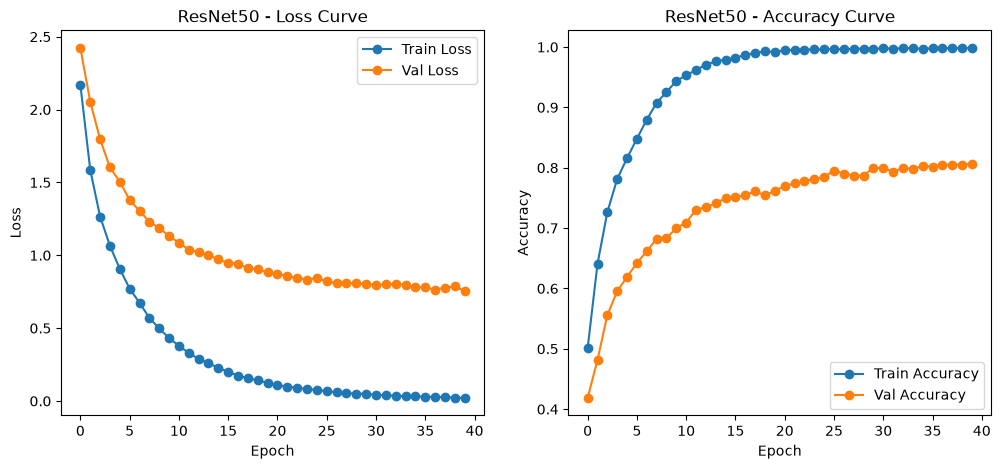

In [72]:
# 1. Load Data
train_loader_res, val_loader_res, test_loader_res = create_dataloaders(img_size=224, resize_size=256)

# 2. Init Model
model_res = initialize_model("resnet50")

if TRAIN_RESNET:
    # 3. Phase 1: Train Head Only
    print("\n--- ResNet50 Phase 1: Warm-up ---")
    for param in model_res.parameters(): param.requires_grad = False
    for param in model_res.fc.parameters(): param.requires_grad = True
    opt_res_f1 = optim.Adam(model_res.fc.parameters(), lr=1e-3)
    hist_res_f1 = train_model(model_res, train_loader_res, val_loader_res, opt_res_f1, num_epochs=5)
    
    # 4. Phase 2: Full Fine-Tuning
    print("\n--- ResNet50 Phase 2: Full Fine-Tuning ---")
    for param in model_res.parameters(): param.requires_grad = True
    opt_res_f2 = optim.Adam(model_res.parameters(), lr=1e-5)
    hist_res_f2 = train_model(model_res, train_loader_res, val_loader_res, opt_res_f2, num_epochs=10)
    
    # Save the trained model with timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = f"./models/resnet50_{timestamp}"
    os.makedirs(run_dir, exist_ok=True)
    
    torch.save(model_res.state_dict(), f"{run_dir}/model.pth")
    with open(f"{run_dir}/history.json", "w") as f:
        json.dump(hist_res_f2, f)
    
    # 5. Evaluate
    plot_metrics(hist_res_f2, "ResNet50", save_dir=run_dir)
    generate_confusion_matrix(model_res, test_loader_res, "ResNet50", save_dir=run_dir)
else:
    print("\n--- Loading Pre-Trained ResNet50 ---")
    model_dirs = [d for d in glob.glob('./models/resnet50_*') if os.path.isdir(d)]
    if model_dirs:
        latest_dir = max(model_dirs, key=os.path.getctime)
        print(f"Loading model from: {latest_dir}")
        model_res.load_state_dict(torch.load(f"{latest_dir}/model.pth", map_location=device, weights_only=True))
        
        hist_path = f"{latest_dir}/history.json"
        if os.path.exists(hist_path):
            with open(hist_path, "r") as f:
                loaded_hist = json.load(f)
            plot_metrics(loaded_hist, "ResNet50")
            
        # generate_confusion_matrix(model_res, test_loader_res, "ResNet50")
    else:
        raise FileNotFoundError("No saved ResNet50 runs found in ./models/! Please set TRAIN_RESNET = True")


---


## 5. Pipeline 2: EfficientNet-B4 (380x380)


Compound-scaled architecture requiring a high-resolution 380x380 input.


Created DataLoaders for sizes: BBox Crop -> Pad -> Resize=380 | Batch Size=8
--> Train size: 6923
--> Val size:   1221
--> Test size:  8041

--- Loading Pre-Trained EfficientNet-B4 ---
Loading model from: ./models\efficientnet_b4_20260626_224215


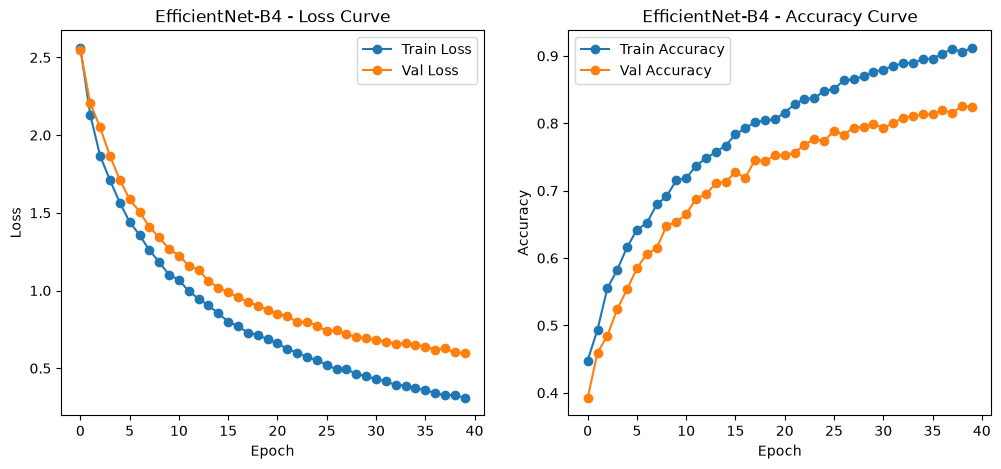

In [73]:
# 1. Load Data
train_loader_eff, val_loader_eff, test_loader_eff = create_dataloaders(img_size=380, resize_size=400, batch_size=8)

# 2. Init Model
model_eff = initialize_model("efficientnet_b4")

if TRAIN_EFFICIENTNET:
    # 3. Phase 1: Train Head Only
    print("\n--- EfficientNet-B4 Phase 1: Warm-up ---")
    for param in model_eff.parameters(): param.requires_grad = False
    for param in model_eff.classifier.parameters(): param.requires_grad = True
    opt_eff_f1 = optim.Adam(model_eff.classifier.parameters(), lr=1e-3)
    hist_eff_f1 = train_model(model_eff, train_loader_eff, val_loader_eff, opt_eff_f1, num_epochs=5)
    
    # 4. Phase 2: Full Fine-Tuning
    print("\n--- EfficientNet-B4 Phase 2: Full Fine-Tuning ---")
    for param in model_eff.parameters(): param.requires_grad = True
    opt_eff_f2 = optim.Adam(model_eff.parameters(), lr=1e-5)
    hist_eff_f2 = train_model(model_eff, train_loader_eff, val_loader_eff, opt_eff_f2, num_epochs=60)
    
    # Save the trained model with timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = f"./models/efficientnet_b4_{timestamp}"
    os.makedirs(run_dir, exist_ok=True)
    
    torch.save(model_eff.state_dict(), f"{run_dir}/model.pth")
    with open(f"{run_dir}/history.json", "w") as f:
        json.dump(hist_eff_f2, f)
    
    # 5. Evaluate
    plot_metrics(hist_eff_f2, "EfficientNet-B4", save_dir=run_dir)
    generate_confusion_matrix(model_eff, test_loader_eff, "EfficientNet-B4", save_dir=run_dir)
else:
    print("\n--- Loading Pre-Trained EfficientNet-B4 ---")
    model_dirs = [d for d in glob.glob('./models/efficientnet_b4_*') if os.path.isdir(d)]
    if model_dirs:
        latest_dir = max(model_dirs, key=os.path.getctime)
        print(f"Loading model from: {latest_dir}")
        model_eff.load_state_dict(torch.load(f"{latest_dir}/model.pth", map_location=device, weights_only=True))
        
        hist_path = f"{latest_dir}/history.json"
        if os.path.exists(hist_path):
            with open(hist_path, "r") as f:
                loaded_hist = json.load(f)
            plot_metrics(loaded_hist, "EfficientNet-B4")
            
        # generate_confusion_matrix(model_eff, test_loader_eff, "EfficientNet-B4")
    else:
        raise FileNotFoundError("No saved EfficientNet-B4 runs found in ./models/! Please set TRAIN_EFFICIENTNET = True")


---


## 6. Interpretability: Grad-CAM Comparison


Side-by-side visual comparison of regions of interest for both ResNet50 and EfficientNet-B4.


Searching for good and bad examples in the validation set...


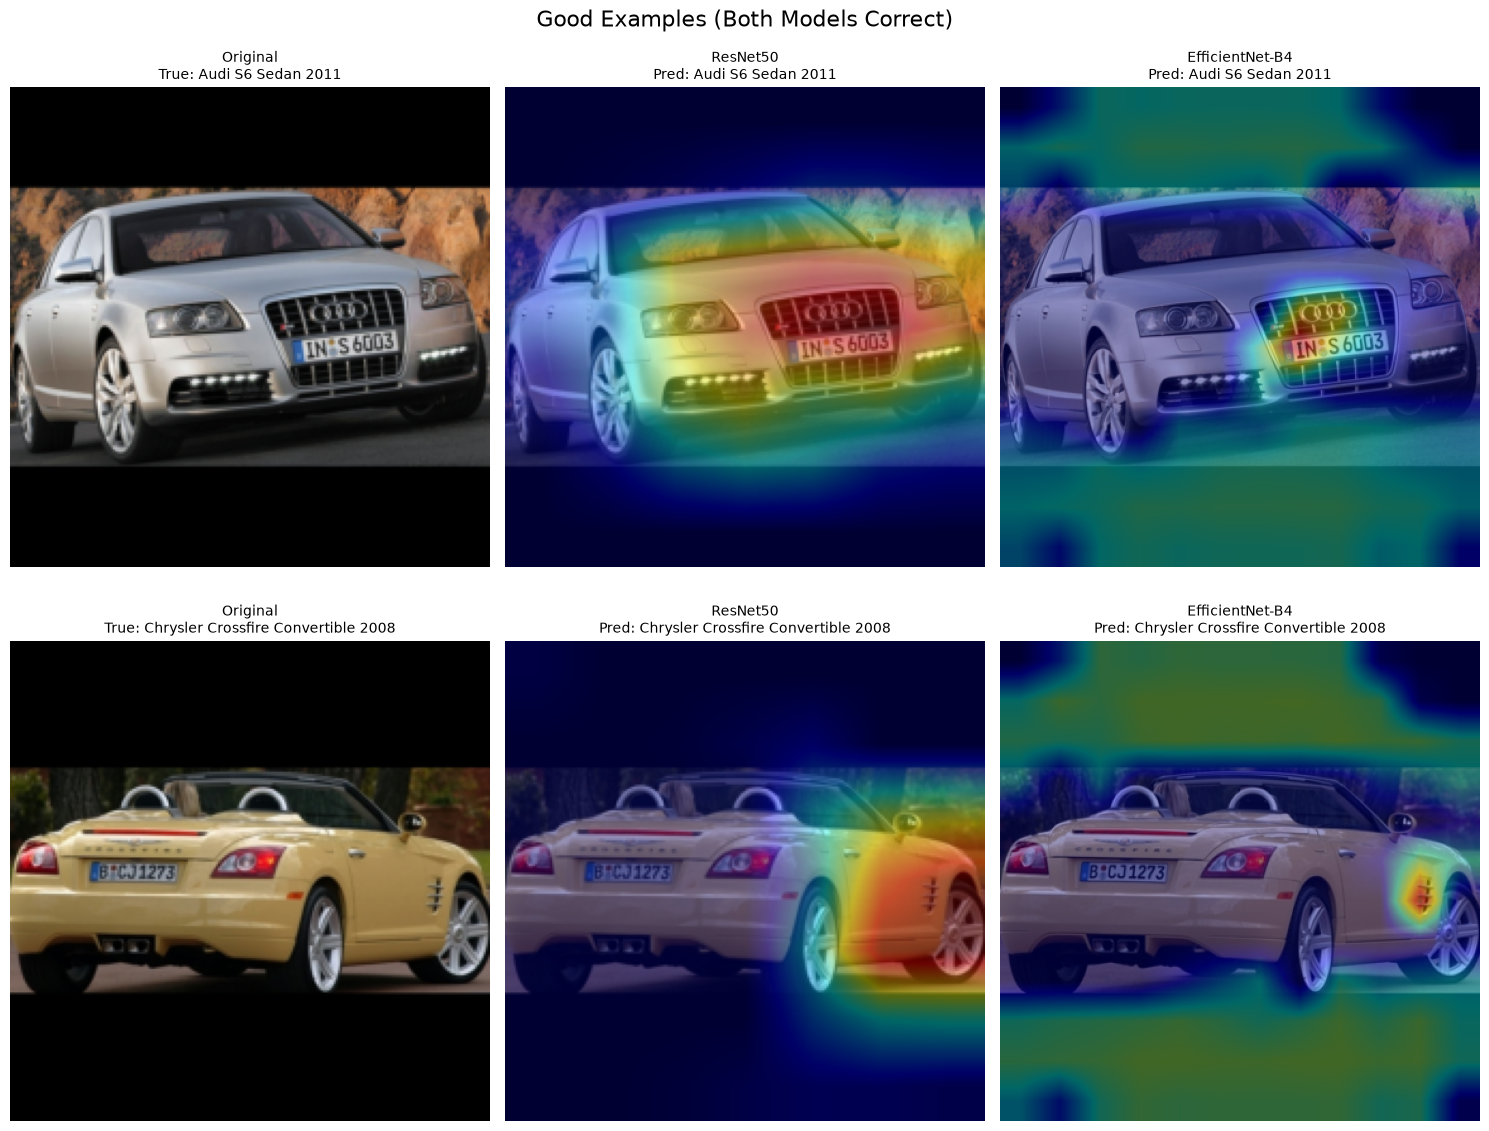

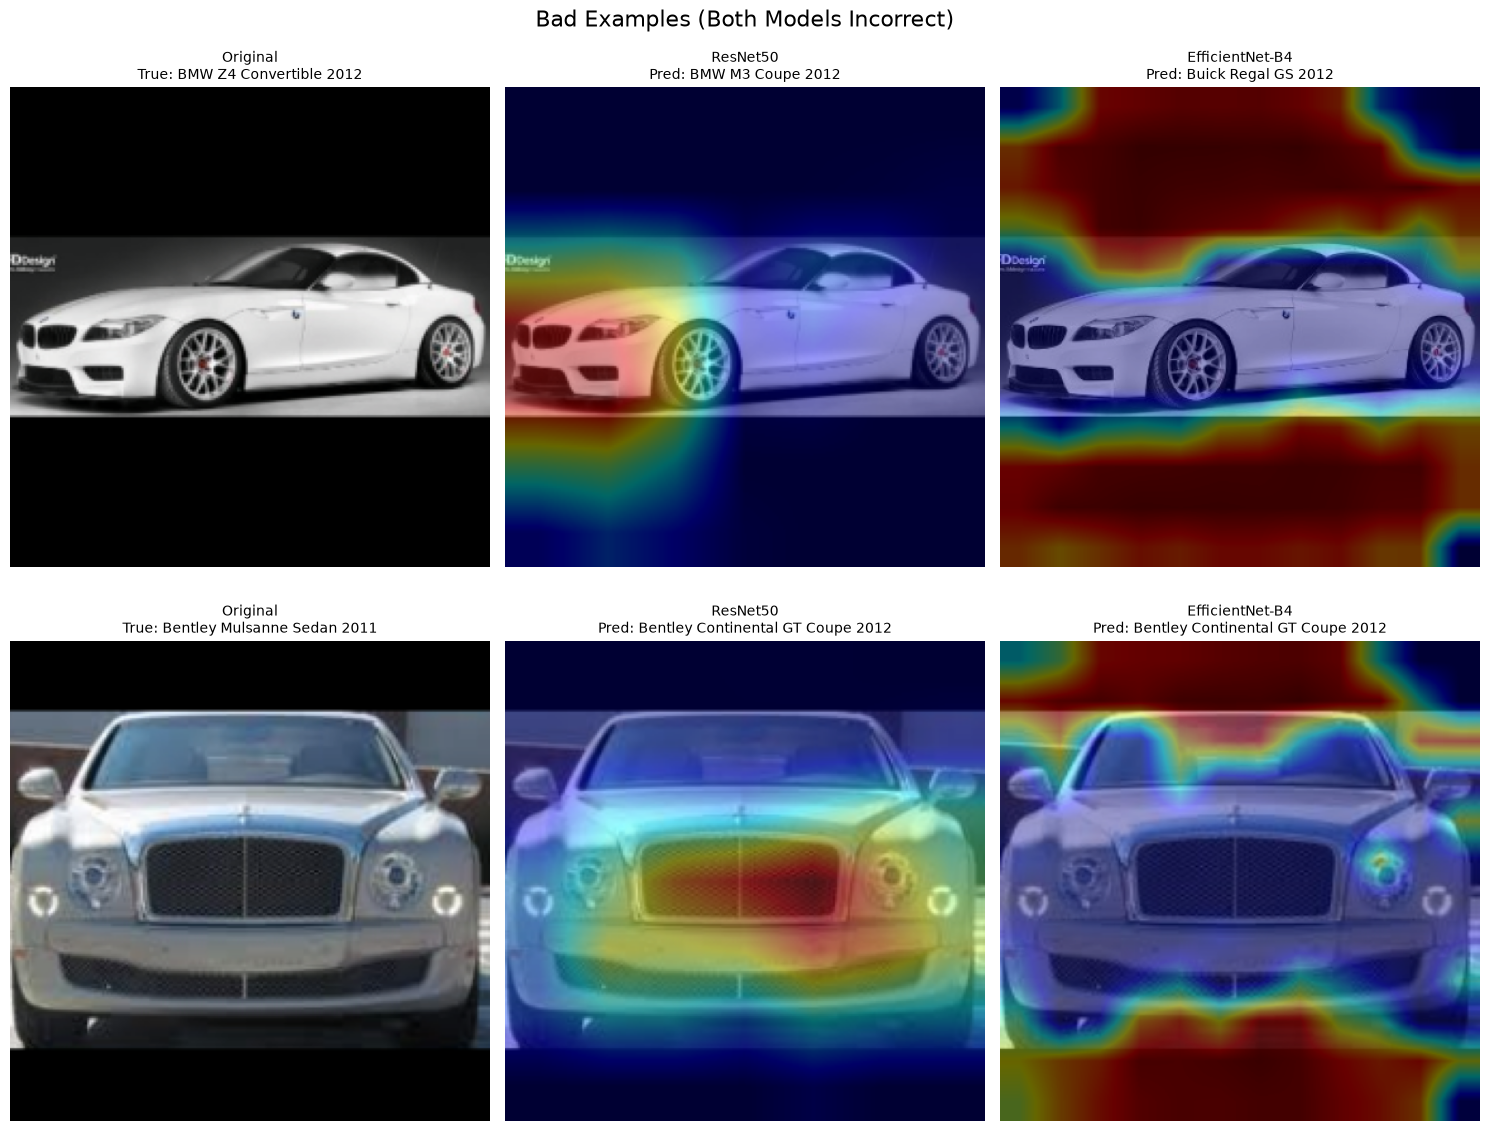

In [74]:
import random
import scipy.io

# Load human-readable class names
meta_mat = scipy.io.loadmat('./data/stanford_cars/devkit/cars_meta.mat')
class_names = [str(c[0][0]) if isinstance(c[0], (list, np.ndarray)) else str(c[0]) for c in meta_mat['class_names'][0]]

# Target layers for Grad-CAM
target_layer_res = model_res.layer4[-1]
target_layer_eff = model_eff.features[-1]

def apply_gradcam_overlay(img_tensor, heatmap):
    heatmap = cv2.resize(heatmap, (img_tensor.shape[3], img_tensor.shape[2]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # Unnormalize img_tensor for visualization
    inv_mean = [-m/s for m, s in zip(mean, std)]
    inv_std = [1/s for s in std]
    inv_transform = transforms.Normalize(mean=inv_mean, std=inv_std)
    
    img = inv_transform(img_tensor.squeeze(0)).permute(1, 2, 0).cpu().numpy()
    img = np.clip(img, 0, 1)
    img = np.uint8(255 * img)
    
    superimposed_img = heatmap * 0.4 + img * 0.6
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
    return img, superimposed_img

good_examples = []
bad_examples = []

model_res.eval()
model_eff.eval()

print("Searching for good and bad examples in the validation set...")
indices = list(range(len(val_loader_res.dataset)))
random.seed(42)
random.shuffle(indices)

for idx in indices:
    if len(good_examples) >= 2 and len(bad_examples) >= 2:
        break
        
    img_res, label_res = val_loader_res.dataset[idx]
    img_eff, label_eff = val_loader_eff.dataset[idx]
    
    img_res = img_res.unsqueeze(0).to(device)
    img_eff = img_eff.unsqueeze(0).to(device)
    
    with torch.set_grad_enabled(True):
        output_res = model_res(img_res)
        pred_res = output_res.argmax(dim=1).item()
        
        output_eff = model_eff(img_eff)
        pred_eff = output_eff.argmax(dim=1).item()
        
    is_correct_res = (pred_res == label_res)
    is_correct_eff = (pred_eff == label_eff)
    
    example_data = {
        'idx': idx, 
        'label_name': class_names[label_res],
        'img_res': img_res, 'pred_res_name': class_names[pred_res],
        'img_eff': img_eff, 'pred_eff_name': class_names[pred_eff]
    }
    
    if is_correct_res and is_correct_eff and len(good_examples) < 2:
        good_examples.append(example_data)
    elif not is_correct_res and not is_correct_eff and len(bad_examples) < 2:
        bad_examples.append(example_data)

def plot_cam_examples(examples, title):
    fig, axes = plt.subplots(len(examples), 3, figsize=(15, 6 * len(examples)))
    fig.suptitle(title, fontsize=16)
    
    for i, ex in enumerate(examples):
        heatmap_res, _ = generate_gradcam(model_res, target_layer_res, ex['img_res'])
        heatmap_eff, _ = generate_gradcam(model_eff, target_layer_eff, ex['img_eff'])
        
        orig_res, overlay_res = apply_gradcam_overlay(ex['img_res'], heatmap_res)
        orig_eff, overlay_eff = apply_gradcam_overlay(ex['img_eff'], heatmap_eff)
        
        # Original
        axes[i, 0].imshow(orig_res)
        axes[i, 0].set_title(f"Original\nTrue: {ex['label_name']}", fontsize=10)
        axes[i, 0].axis('off')
        
        # ResNet
        axes[i, 1].imshow(overlay_res)
        axes[i, 1].set_title(f"ResNet50\nPred: {ex['pred_res_name']}", fontsize=10)
        axes[i, 1].axis('off')
        
        # EfficientNet
        axes[i, 2].imshow(overlay_eff)
        axes[i, 2].set_title(f"EfficientNet-B4\nPred: {ex['pred_eff_name']}", fontsize=10)
        axes[i, 2].axis('off')
        
    plt.tight_layout()
    plt.show()

if good_examples:
    plot_cam_examples(good_examples, "Good Examples (Both Models Correct)")
if bad_examples:
    plot_cam_examples(bad_examples, "Bad Examples (Both Models Incorrect)")

